In [1]:
import numpy as np
from matplotlib import pyplot as plt

# What this document is about

This document explores the design behind `hart::PinkNoise` signal.

Pink noise is tricky to generate in time domain, as it involves a very specific frequency response slope, that is hard to obtain through a simple filter. I've made `hart::Spectrum::colouredNoise()` factory that is convertible to `hart::AudioBuffer` and `hart::Signal`, but it still has some downsides, specifically:

a) it's not naturally infinite, unlike most other HART signals

b) it's pretty computationally expensive, as it requires IFFT to move to time domain

So, I had a very accurate pink noise generator in HART, but I still felt that it needs something that doesn't have those downsides, as a reasonable alternative. I've come across this old article from 1999: https://www.firstpr.com.au/dsp/pink-noise/ . Among other things, it showcased Paul Kellet's "instrumentation grade" filter design. It's a few simple filters, that produce a very accurate frequency response curve, that can be applied to white noise to "pinkify" it:

```
b0 = 0.99886 * b0 + white * 0.0555179;
b1 = 0.99332 * b1 + white * 0.0750759;
b2 = 0.96900 * b2 + white * 0.1538520;
b3 = 0.86650 * b3 + white * 0.3104856;
b4 = 0.55000 * b4 + white * 0.5329522;
b5 = -0.7616 * b5 - white * 0.0168980;
pink = b0 + b1 + b2 + b3 + b4 + b5 + b6 + white * 0.5362;
b6 = white * 0.115926;
```

Actually, that article also contains an "economy" version of this filter, with less poles, but the "fancy" (in 1990s terms) version of this filter is cheap enough for 2020s machines, even the modest VMs that you might use in your CI pipelines to run automated tests, so this is what ended up under the hood of `hart::PinkNoise`.

There's one serious concern with it, though: it's designed specifically for 44.1 kHz sampling rate, and HART is designed to operate at arbitrary sample rates. And apparently the coefficients are hand-tuned, so while coming up with a sample-rate-independent version of it could be a valuable contribution to the DSP world, it's actually not that necessary, at least in the context of HART. Given the nature of this filter, the only issue is that its response will be less accurate at the very low end at higher sample rates. So, one of the things I'm doing here is checking if it's bad enough to be worried about, and apparently it's quite acceptable.

Regardless, HART's philosophy involves having some contracts and promises regarding the quality of the produced signal, so I'm estimating some tolerances to put into this signal's documentation.

Another thing that this document addresses if this filter's output scaling. For a white noise with a -1..+1 range, it produces quite hot signal, while most signals in HART default to sample peaks at unity gain. It's impossible to guarantee specific sample peak values with this type of signal, so I'm adjusting its RMS instead.

Finally, there's a section on warming-up the filter somewhere in between.

Everything here is done in 64-bit floats, and the estimated calibration const values will be the same for both 64-bit `PinkNoise<double>` and 32-bit `PinkNoise<float>` C++ implementations.

# Frequency response

This is an implementation of this filter. Pretty much a verbatim implementation of the original.  `hart::PinkNoise` does the same, but multi-channel.

In [2]:
class PinkingFilter:
    def __init__(self):
        self.b0 = 0
        self.b1 = 0
        self.b2 = 0
        self.b3 = 0
        self.b4 = 0
        self.b5 = 0
        self.b6 = 0

    def process(self, white_samples: np.array) -> np.array:
        pink_samples = np.empty_like(white_samples)
        
        for i in range(white_samples.size):
            white = white_samples[i]

            self.b0 = 0.99886 * self.b0 + white * 0.0555179;
            self.b1 = 0.99332 * self.b1 + white * 0.0750759;
            self.b2 = 0.96900 * self.b2 + white * 0.1538520;
            self.b3 = 0.86650 * self.b3 + white * 0.3104856;
            self.b4 = 0.55000 * self.b4 + white * 0.5329522;
            self.b5 = -0.7616 * self.b5 - white * 0.0168980;
            pink = self.b0 + self.b1 + self.b2 + self.b3 + self.b4 + self.b5 + self.b6 + white * 00.5362;
            self.b6 = white * 0.115926;

            pink_samples[i] = pink

        return pink_samples

This is frequency response of this filter, as compared to ideal pink noise response. The article claims it to be accurate to within +/-0.05dB above 9.2Hz (marked with the dashed line) at 44.1 kHz. But in fact, the accuracy above this frequency is even better, in 0.03 dB range.

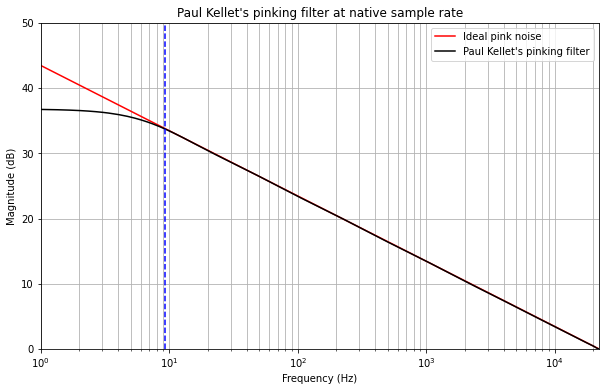

In [3]:
native_sample_rate_hz = 44100
num_frames = 1 << 17

impulse = np.zeros(num_frames, dtype=np.float64)
impulse[0] = 1.0

pinking_filter = PinkingFilter()

# IR and frequency response of the filter
pinking_filter_impulse_response = pinking_filter.process(impulse)
pinking_filter_frequency_response_complex = np.fft.rfft(pinking_filter_impulse_response)
frequencies_hz = np.fft.rfftfreq(num_frames, d=1.0 / native_sample_rate_hz)
pinking_filter_frequency_response_db = 20.0 * np.log10(np.maximum(np.abs(pinking_filter_frequency_response_complex), 1e-15))

# Skip DC in the plot
mask = frequencies_hz > 0
frequencies_plot_hz = frequencies_hz[mask]
pinking_filter_frequency_response_plot_db = pinking_filter_frequency_response_db[mask]

# Ideal pink noise spectrum
reference_frequency_hz = 1000.0
reference_frequency_index = np.argmin(np.abs(frequencies_plot_hz - reference_frequency_hz))
reference_frequency_magnitude_db = pinking_filter_frequency_response_plot_db[reference_frequency_index]
ideal_frequency_response_db = reference_frequency_magnitude_db - 10.0 * np.log10(frequencies_plot_hz / reference_frequency_hz)

plt.figure(figsize=(10, 6))

plt.semilogx(frequencies_plot_hz, ideal_frequency_response_db, label="Ideal pink noise", color='red')
plt.semilogx(frequencies_plot_hz, pinking_filter_frequency_response_plot_db, label="Paul Kellet's pinking filter", color='black')

plt.title('Paul Kellet\'s pinking filter at native sample rate')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which='both')
plt.xlim(1, native_sample_rate_hz / 2)
plt.ylim(0, 50)
plt.axvline(x=9.2, color='blue', linestyle='--')  # Accurate above this frequency
plt.legend()
plt.show()

If we use the same coefficients at a higher sample rate, namely 96kHz, the flat section of its frequency response will crawl up (blue dashed line). But, as we can see, at 20 Hz (olive dashed line), it's still pretty tight to the ideal curve. However, at even higher sample rates it's harder to ignore, which will be explored below

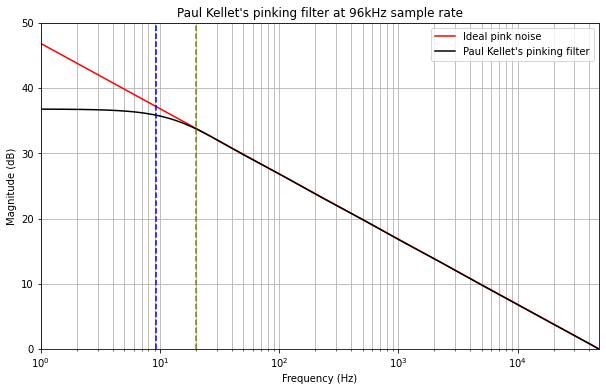

In [4]:
higher_sample_rate_hz = 96000.0
frequencies_at_higher_sample_rate_hz = frequencies_plot_hz * (higher_sample_rate_hz / native_sample_rate_hz)

plt.figure(figsize=(10, 6))

plt.semilogx(frequencies_at_higher_sample_rate_hz, ideal_frequency_response_db, label="Ideal pink noise", color='red')
plt.semilogx(frequencies_at_higher_sample_rate_hz, pinking_filter_frequency_response_plot_db, label="Paul Kellet's pinking filter", color='black')

plt.title('Paul Kellet\'s pinking filter at 96kHz sample rate')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which='both')
plt.xlim(1, higher_sample_rate_hz / 2)
plt.ylim(0, 50)
plt.axvline(x=9.2, color='blue', linestyle='--')  # No longer super accurate at 9.2Hz...
plt.axvline(x=20, color='olive', linestyle='--')  # ...but still okay at 20Hz
plt.legend()
plt.show()

At lower sample rates, there's no concern, really. The filter design involves a couple of stages to fix near-Nyquist ripple, and it performs nicely there, so it doesn't become a problem at low sample rates.

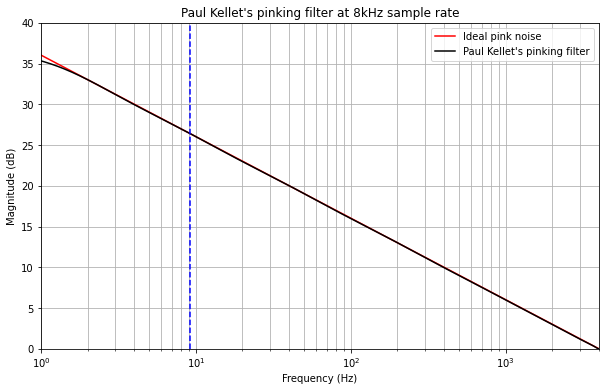

In [5]:
lower_sample_rate_hz = 8000.0
frequencies_at_higher_sample_rate_hz = frequencies_plot_hz * (lower_sample_rate_hz / native_sample_rate_hz)

plt.figure(figsize=(10, 6))

plt.semilogx(frequencies_at_higher_sample_rate_hz, ideal_frequency_response_db, label="Ideal pink noise", color='red')
plt.semilogx(frequencies_at_higher_sample_rate_hz, pinking_filter_frequency_response_plot_db, label="Paul Kellet's pinking filter", color='black')

plt.title('Paul Kellet\'s pinking filter at 8kHz sample rate')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, which='both')
plt.xlim(1, lower_sample_rate_hz / 2)
plt.ylim(0, 40)
plt.axvline(x=9.2, color='blue', linestyle='--')  # No longer super accurate at 9.2Hz...
plt.legend()
plt.show()

# Estimating accuracy at various sample rates

Now let's calculate the same response, but with more points, producing an IR close to an infinite one, to estimate its accuracy

In [6]:
num_frames = 1 << 22

impulse = np.zeros(num_frames, dtype=np.float64)
impulse[0] = 1.0

pinking_filter = PinkingFilter()

pinking_filter_impulse_response = pinking_filter.process(impulse)
pinking_filter_frequency_response_complex = np.fft.rfft(pinking_filter_impulse_response)
frequencies_hz = np.fft.rfftfreq(num_frames, d=1.0 / native_sample_rate_hz)
pinking_filter_frequency_response_db = 20.0 * np.log10(np.maximum(np.abs(pinking_filter_frequency_response_complex), 1e-15))

Author claims the accuracy of the response to be within 0.05 dB. But analyzing the observed filter's frequency response shows that it's even better, in 0.03-ish dB range, depending on number of IR points:

In [7]:
mask = (frequencies_hz >= 9.2) & (frequencies_hz <= native_sample_rate_hz / 2)

measured_db = pinking_filter_frequency_response_db[mask]
ideal_db = -10.0 * np.log10(frequencies_hz[mask])

difference_db = measured_db - ideal_db
offset_db = 0.5 * (np.max(difference_db) + np.min(difference_db))
error_db = difference_db - offset_db
max_error_db = np.max(np.abs(error_db))

print('Observed deviation above 9.2Hz threshold at native sample rate, dB:')
print(max_error_db)

Observed deviation above 9.2Hz threshold at native sample rate, dB:
0.03459202460099675


But this filter is designed, and apparently hand-tuned, for 44.1 kHz. It's actually usable at arbitrary sample rate, with the exception that this 9.2 Hz threshold will move higher, as sample rate increases. We'll just treat the 44.1 kHz frequency response as relative frequency space, and see what the listed 9.2 Hz threshold translates into for arbitrary sample rates. Naturally, as sample rate increases, this threshold will move up.

In [8]:
target_sample_rates_hz = [44100, 48000, 88200, 96000, 176400, 192000]
print('Equivalent +/-0.05 dB lower-frequency threshold at common sample rates')
print('------------ | --------------')
print('             | Threshold')
print('Sample rate, | equivalent at')
print('     Hz      | target SR, Hz')
print('------------ | --------------')

for target_sample_rate_hz in target_sample_rates_hz:
    equivalent_threshold_hz = 9.2 * target_sample_rate_hz / native_sample_rate_hz

    print(f'{target_sample_rate_hz:12} | {equivalent_threshold_hz:13.2f}')

Equivalent +/-0.05 dB lower-frequency threshold at common sample rates
------------ | --------------
             | Threshold
Sample rate, | equivalent at
     Hz      | target SR, Hz
------------ | --------------
       44100 |          9.20
       48000 |         10.01
       88200 |         18.40
       96000 |         20.03
      176400 |         36.80
      192000 |         40.05


At high sample rates, this 9.2 Hz equivalent "moves" well into an audible range: 40.05 Hz at 192kHz sample rate is pretty much a low E string on a usual bass. Not a very useful threshold for instrument-grade audio tests... So we'll discard the claimed threshold completely, and at every common sample rate, we'll measure deviations above 20Hz (actual 20Hz at each sample rate, not equivalent).

In [9]:
target_sample_rates_hz = [44100, 48000, 88200, 96000, 176400, 192000]

print('Maximum spectral-shape error above 20 Hz after optimal')
print('constant gain alignment at common sample rates')
print('------------ | ------------- | -----------')
print('             | Threshold     |')
print('Sample rate, | equivalent at | Max error,')
print('     Hz      | native SR, Hz |     dB')
print('------------ | ------------- | -----------')

for target_sample_rate_hz in target_sample_rates_hz:
    equivalent_threshold_hz = 20.0 * native_sample_rate_hz / target_sample_rate_hz
    mask = (frequencies_hz >= equivalent_threshold_hz) & (frequencies_hz <= native_sample_rate_hz / 2)

    measured_db = pinking_filter_frequency_response_db[mask]
    ideal_db = -10.0 * np.log10(frequencies_hz[mask])

    difference_db = measured_db - ideal_db
    offset_db = 0.5 * (np.max(difference_db) + np.min(difference_db))
    error_db = difference_db - offset_db
    max_error_db = np.max(np.abs(error_db))

    print(f'{target_sample_rate_hz:12} | {equivalent_threshold_hz:13.2f} | {max_error_db:11.3f}')

Maximum spectral-shape error above 20 Hz after optimal
constant gain alignment at common sample rates
------------ | ------------- | -----------
             | Threshold     |
Sample rate, | equivalent at | Max error,
     Hz      | native SR, Hz |     dB
------------ | ------------- | -----------
       44100 |         20.00 |       0.029
       48000 |         18.38 |       0.029
       88200 |         10.00 |       0.030
       96000 |          9.19 |       0.035
      176400 |          5.00 |       0.460
      192000 |          4.59 |       0.562


# Filter warm-up

We want to have a filter in a warmed-up state ready at any time. We'll calculate it based on the slowest pole's time constant, and target residual error:

In [10]:
a = 0.99886  # Slowest pole
tau_frames = -1.0 / np.log (a)

target_epsilon = 5e-5  # Maximum remaining fraction of initial-state error
warm_up_duration_frames = int(np.ceil(np.log(target_epsilon) / np.log(a)))

print(f'Tau of slowest pole: {tau_frames:0.2f} frames')
print(f'Warm-up duration: {warm_up_duration_frames} frames, {(warm_up_duration_frames / tau_frames):0.2f} taus')

Tau of slowest pole: 876.69 frames
Warm-up duration: 8683 frames, 9.90 taus


And the bit for C++ code:

In [11]:
print(f'constexpr size_t warmUpDurationFrames = {warm_up_duration_frames};')

constexpr size_t warmUpDurationFrames = 8683;


# Output level calibration

If we run a white noise with -1..+1 range through the filter, the output is pretty hot:

In [12]:
global_rng_seed = 123
rng = np.random.default_rng(global_rng_seed)

pinking_filter = PinkingFilter()

# Warm-up
white_noise = rng.uniform(-1, 1, warm_up_duration_frames)
pinking_filter.process(white_noise)

white_noise = rng.uniform(-1, 1, 5000)
pink_noise = pinking_filter.process(white_noise)

input_sample_peak_linear = np.abs(white_noise).max()
output_sample_peak_linear = np.abs(pink_noise).max()

input_sample_peak_db = 20 * np.log10(input_sample_peak_linear)
output_sample_peak_db = 20 * np.log10(output_sample_peak_linear)

print(f'Before input scaling:')
print(f'White noise (input) sample peak: {input_sample_peak_linear:+0.3f} linear, or {input_sample_peak_db:+0.2f} dB')
print(f'Pink noise (output) sample peak: {output_sample_peak_linear:+0.3f} linear, or {output_sample_peak_db:+0.2f} dB')

Before input scaling:
White noise (input) sample peak: +1.000 linear, or -0.00 dB
Pink noise (output) sample peak: +5.332 linear, or +14.54 dB


So it's a good idea to scale it down quite a bit. Any specific sample peak target isn't very meaningful for pink noise, as it will vary with seed and render duration, so we'll calibrate the RMS instead.

In [13]:
h = pinking_filter_impulse_response
sum_h_squared = (h * h).sum()
sigma_white_squared = 1 / 3
raw_rms_linear = np.sqrt(sum_h_squared * sigma_white_squared)
raw_rms_db = 20 * np.log10 (raw_rms_linear)
print(f'Raw RMS: {raw_rms_linear:0.2f} linear, or {raw_rms_db:+0.2f} dB')

Raw RMS: 1.76 linear, or +4.92 dB


In [14]:
target_rms_db = -12.0
target_rms_linear = 10 ** (target_rms_db / 20)
assert raw_rms_linear > 1e-8
white_noise_peak_linear = target_rms_linear / raw_rms_linear
white_noise_peak_db = 20 * np.log10 (white_noise_peak_linear)
print(f'Target RMS: {target_rms_linear:0.3f} linear, or {target_rms_db:+0.2f} dB')
print(f'Adjusted white noise peak: {white_noise_peak_linear:0.3f} linear, or {white_noise_peak_db:+0.2f} dB')

Target RMS: 0.251 linear, or -12.00 dB
Adjusted white noise peak: 0.143 linear, or -16.92 dB


A value to use in the HART C++ code:

In [15]:
print(f'static constexpr SampleType whiteNoisePeakLinear = (SampleType) {white_noise_peak_linear:0.15f};')

static constexpr SampleType whiteNoisePeakLinear = (SampleType) 0.142528277179462;


So, instead of -1..+1 white noise range, we can use the adjusted white noise peak value - it will act as a make-up gain, to achieve target RMS, while keeping sample peaks around unity gain.

Now, let's measure sample peaks. On one hand sample peak isn't very meaningful in the context of pink noise, but on the other, a lot of potential DSP testees are sensitive to sample peak levels. We'll render a bunch of consecutive short (~100ms at 44.1kHz) bits of audio, and see where the peaks land. The primary contract is RMS, but let's see if this adjusted RMS puts the peaks around unity gain.

Here are observed values for one short piece of audio:

In [16]:
pinking_filter = PinkingFilter()

# Warm-up
white_noise = rng.uniform(-white_noise_peak_linear, white_noise_peak_linear, warm_up_duration_frames)
pinking_filter.process(white_noise)

white_noise = rng.uniform(-white_noise_peak_linear, white_noise_peak_linear, 5000)
pink_noise = pinking_filter.process(white_noise)

input_sample_peak_linear = np.abs(white_noise).max()
output_sample_peak_linear = np.abs(pink_noise).max()

input_sample_peak_db = 20 * np.log10(input_sample_peak_linear)
output_sample_peak_db = 20 * np.log10(output_sample_peak_linear)

print(f'After input scaling:')
print(f'White noise (input) sample peak: {input_sample_peak_linear:+0.3f} linear, or {input_sample_peak_db:+0.2f} dB')
print(f'Pink noise (output) sample peak: {output_sample_peak_linear:+0.3f} linear, or {output_sample_peak_db:+0.2f} dB')

After input scaling:
White noise (input) sample peak: +0.142 linear, or -16.92 dB
Pink noise (output) sample peak: +0.944 linear, or -0.50 dB


And here are a bunch of those:

In [17]:
sample_peaks_db = np.empty(1000, dtype=np.float64)

for i in range(sample_peaks_db.size):
    white_noise = np.random.uniform(-white_noise_peak_linear, white_noise_peak_linear, 5000)
    pink_noise = pinking_filter.process(white_noise)
    output_sample_peak_linear = np.abs(pink_noise.max())
    output_sample_peak_db = 20 * np.log10(output_sample_peak_linear)

    sample_peaks_db[i] = output_sample_peak_db

In [18]:
median = np.percentile(sample_peaks_db, 50)
p95 = np.percentile(sample_peaks_db, 95)
print(f'Output sample peaks')
print(f'Median: {median:+0.2f} dB')
print(f'P95: {p95:+0.2f} dB')

Output sample peaks
Median: -2.37 dB
P95: -0.23 dB


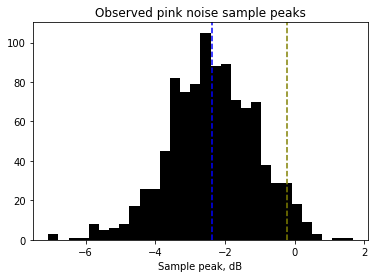

In [19]:
plt.hist(sample_peaks_db, bins=30, color='black')
plt.axvline(x=median, color='blue', linestyle='--')
plt.axvline(x=p95, color='olive', linestyle='--')
plt.title ('Observed pink noise sample peaks')
plt.xlabel('Sample peak, dB')
plt.show()

So, this concludes the `hart::PinkNoise` design notes.